### **Step 1: Import Libraries**

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### **Step 2: Load Dataset**

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **Step 3: Explore the Data**

In [4]:
print("Shape:", df.shape)
print()
print(df.info())
print("Missing values:\n", df.isnull().sum())

Shape: (891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin         

### **Step 4: Preprocessing**

In [5]:
# Drop columns not useful for prediction
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode Sex: male=1, female=0
le_sex = LabelEncoder()
df["Sex"] = le_sex.fit_transform(df["Sex"])

# Encode Embarked: C=0, Q=1, S=2
le_emb = LabelEncoder()
df["Embarked"] = le_emb.fit_transform(df["Embarked"])

print("After preprocessing:")
print(df.isnull().sum())
df.head()

After preprocessing:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### **Step 5: Separate Features (X) and Target (y)**

In [6]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


### **Step 6: Train-Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (623, 7)
Testing size: (268, 7)


### **Step 7: Train the Model**

In [8]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


### **Step 8: Evaluate the Model**


In [9]:
y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

Accuracy: 0.8134328358208955

              precision    recall  f1-score   support

Not Survived       0.82      0.87      0.85       157
    Survived       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



### **Step 9: Confusion Matrix**

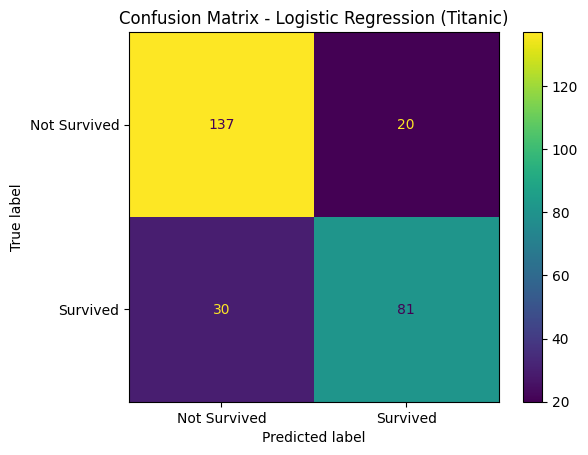

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression (Titanic)")
plt.show()

### **Step 10: External Prediction**

In [11]:
# New passenger: 3rd class, female, age 25, no siblings, no parents,
# fare 7.5, embarked from S
new_passenger = [[3, 0, 25, 0, 0, 7.5, 2]]
new_passenger_df = pd.DataFrame(new_passenger, columns=X.columns)

result = log_reg.predict(new_passenger_df)[0]
print("Prediction:", "Survived" if result == 1 else "Not Survived")

Prediction: Survived
